# 🏷️ **Project Name**
Integrated Retail Analytics for Store Optimization


##### 📊 **Project Type**
EDA / Regression / Time Series Forecasting / Unsupervised Learning


# 📝 **Project Summary**


📌 **Selected Category:** Category 2 - Personalized Customer Segmentation in E-commerce / Retail

Retail businesses do not lose money only because sales are low. They also lose money when stores are planned in the same way even though they behave differently, when demand spikes are treated as normal, when promotions are not reviewed properly, and when inventory decisions are made without a clear view of upcoming demand. This project is built around that business problem.

The dataset represents weekly Walmart sales across **45 stores**, **81 departments**, and dates from **February 2010 to October 2012**. The sales table tells us what was sold, where it was sold, and during which week. The features table adds the weekly business environment around those sales, such as markdown activity, weather, fuel price, CPI, unemployment, and holiday timing. The stores table adds the identity of each store through store type and size. Together, these tables allow the project to move from raw sales records to a more complete retail decision view.

The selected category is retail segmentation, so store grouping is an important part of the project. However, the project description also asks for anomaly detection, market basket analysis, demand forecasting, external factors, and business strategy. For that reason, the notebook builds an integrated retail analytics workflow rather than a single-model exercise.

The work starts with data understanding, cleaning, and feature engineering. It then studies sales patterns through visual analysis and hypothesis testing. After that, it identifies unusual sales behavior, creates store segments, builds proxy department association rules, and compares forecasting models. The forecasting section includes both an overall weekly sales model for strategic demand planning and a store-department benchmark for more operational demand tracking.

🎯 **Project goal:** turn weekly retail data into practical insights that can support inventory planning, promotion review, store segmentation, anomaly monitoring, and demand forecasting in a business-friendly way.


# **GitHub Link -**


[GitHub Repository](https://github.com/I-AM-PRASHANT-VERMA/Almabetter---Integrated-Retail-Analytics-for-Store-Optimization-)


# 🎯 **Problem Statement**


The business problem is to understand how different stores, departments, promotions, holidays, and external conditions affect weekly retail sales. A store manager or retail planning team cannot make strong decisions by looking only at total sales. They need to know which stores behave similarly, which departments drive revenue, which weeks are unusual, and which demand patterns can be forecasted with reasonable confidence.

📍 **What this project is trying to achieve**

- 🛒 Understand the structure and quality of the sales, features, and stores data.
- 🧹 Create a clean merged dataset that connects sales with store information and weekly business conditions.
- 📈 Study sales patterns across time, holidays, store types, departments, markdowns, and economic variables.
- 🚨 Detect unusual sales weeks so they can be reviewed instead of blindly treated as normal.
- 🧩 Segment stores into useful business groups for differentiated planning.
- 🧺 Build proxy department association rules because true customer basket data is not available.
- 🔮 Forecast demand using class-aligned time-series methods and compare model performance clearly.

The final aim is not only prediction. The aim is to explain what is happening in the retail network and convert that understanding into better planning decisions.


# 📋 **General Guidelines**  


1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.


# 🚀 ***Let's Begin!***


## 🔍 ***1. Know Your Data***


### 📚 Import Libraries


In [1]:
# Code Cell 00: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

print('Google Drive mounted successfully')


Mounted at /content/drive
Google Drive mounted successfully


In [2]:
# Code Cell 01: Import required libraries

import importlib
import io
import json
import subprocess
import sys
import warnings
from pathlib import Path

REQUIRED_PACKAGES = {
    'statsmodels': 'statsmodels',
    'mlxtend': 'mlxtend',
}

# Install missing packages only when needed.
for package_name, import_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import f_oneway, mannwhitneyu, spearmanr
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Basic notebook settings.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

RANDOM_STATE = 42

print('Notebook setup is ready')


Notebook setup is ready


### 💾 Dataset Loading


In [3]:
# Code Cell 02: Load Dataset

# Load the three source datasets from Google Drive.
sales_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/sales data-set.csv')
features_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/Features data set.csv')
stores_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/stores data-set.csv')

# Confirm loading.
print('Datasets loaded successfully')


Datasets loaded successfully


### 👀 Dataset First View


In [4]:
# Code Cell 03: Dataset first look.

# Show first rows from the sales dataset.
print('SALES DATASET')
display(sales_df.head())

# Show first rows from the features dataset.
print('FEATURES DATASET')
display(features_df.head())

# Show first rows from the stores dataset.
print('STORES DATASET')
display(stores_df.head())


SALES DATASET


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,"24,924.50",False
1,1,1,12/02/2010,"46,039.49",True
2,1,1,19/02/2010,"41,595.55",False
3,1,1,26/02/2010,"19,403.54",False
4,1,1,05/03/2010,"21,827.90",False


FEATURES DATASET


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,12/02/2010,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,19/02/2010,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,26/02/2010,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,05/03/2010,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


STORES DATASET


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


🧾 **Reading the output**

The preview confirms that the project is built from three connected business tables:

- **Sales table:** This is the main activity table. Each row records weekly sales for a specific `Store` and `Dept`. `Weekly_Sales` is the target business value, and `IsHoliday` marks whether the week is treated as a holiday week.
- **Features table:** This table explains the weekly environment around each store. `Temperature` represents local weather, `Fuel_Price` represents transport/economic pressure, `CPI` reflects consumer price level, and `Unemployment` reflects local economic stress. `MarkDown1` to `MarkDown5` represent different discount or promotion fields. A markdown means the retailer reduced price or ran a promotional offer to influence sales.
- **Stores table:** This table gives stable store identity. `Type` tells the store category, and `Size` tells how large the store is.

📌 **Business meaning**

Sales tells us **what happened**, features help explain **what conditions existed when it happened**, and stores tell us **what kind of store produced those sales**. This is enough to build a business view of demand instead of looking at sales numbers alone.


### 📐 Dataset Rows & Columns count


In [5]:
# Code Cell 04: Check rows and columns for each dataset.

# Create a compact shape summary for all source tables.
dataset_count_df = pd.DataFrame(
    {
        'Dataset': ['Sales', 'Features', 'Stores'],
        'Rows': [sales_df.shape[0], features_df.shape[0], stores_df.shape[0]],
        'Columns': [sales_df.shape[1], features_df.shape[1], stores_df.shape[1]],
    }
)

# Display dataset sizes.
display(dataset_count_df)


,Dataset,Rows,Columns
0,Sales,421570,5
1,Features,8190,12
2,Stores,45,3


### ℹ️ Dataset Information


In [6]:
# Code Cell 05: Check dataset information.

# Capture .info() output so it appears neatly in the notebook.
def capture_info(dataframe):
    buffer = io.StringIO()
    dataframe.info(buf=buffer)
    return buffer.getvalue()

# Review structure, data types, and memory usage for each raw table.
display(Markdown("#### Sales Dataset Info"))
print(capture_info(sales_df))

display(Markdown("#### Features Dataset Info"))
print(capture_info(features_df))

display(Markdown("#### Stores Dataset Info"))
print(capture_info(stores_df))


#### Sales Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB



#### Features Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB



#### Stores Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB



🏗️ **Reading the output**

The `.info()` output confirms that the sales table is the largest table with **421,570 rows**, while the features table has **8,190 rows** and the stores table has only **45 rows**. This makes sense for the business: sales are recorded at a detailed store-department-week level, features are recorded weekly for each store, and store details are recorded once per store.

📌 **Important points**

- `Date` is loaded as text at first, so it must be converted before time-series work.
- Sales and store fields are mostly complete, which is good because they form the base of the project.
- Markdown columns have many missing values, so they need a business-aware treatment instead of simple deletion.
- The store table is small and clean, so it can safely act as a lookup table during merging.

The important issue here is not the size difference between tables. That is expected. The important issue is preparing dates and markdown fields correctly before analysis.


#### 👯 Duplicate Values


In [7]:
# Code Cell 06: Check duplicate rows in each dataset.

# Count repeated rows in every source table.
duplicate_summary_df = pd.DataFrame(
    {
        'Dataset': ['Sales', 'Features', 'Stores'],
        'Duplicate Rows': [
            sales_df.duplicated().sum(),
            features_df.duplicated().sum(),
            stores_df.duplicated().sum(),
        ],
    }
)

# Display duplicate count summary.
display(duplicate_summary_df)


,Dataset,Duplicate Rows
0,Sales,0
1,Features,0
2,Stores,0


✅ **Reading the output**

All three datasets have **0 duplicate rows**.

📌 **Business meaning**

This is a good sign because there are no repeated raw records that would artificially increase sales, store counts, or feature values. It also means we do not need to remove duplicate rows before merging. The next quality concern is not duplication; it is missing markdown and economic fields in the features table.


#### ⚠️ Missing Values/Null Values


In [8]:
# Code Cell 07: Summarize missing values across all three source datasets.

# Sales missing counts are converted into a compact table.
sales_missing_df = sales_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
sales_missing_df["Dataset"] = "Sales"  # A dataset label is added so the table can later be stacked cleanly.

# Feature missing counts are summarized the same way.
features_missing_df = features_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
features_missing_df["Dataset"] = "Features"  # The dataset label identifies the source table.

# Store missing counts are summarized the same way.
stores_missing_df = stores_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
stores_missing_df["Dataset"] = "Stores"  # The dataset label completes the store summary.

# The three summaries are stacked into one view.
missing_summary_df = pd.concat([sales_missing_df, features_missing_df, stores_missing_df], ignore_index=True)

# The largest gaps are moved to the top for faster review.
missing_summary_df = missing_summary_df.sort_values(["Missing_Values", "Dataset", "Column"], ascending=[False, True, True]).reset_index(drop=True)
display(missing_summary_df)


,Column,Missing_Values,Dataset
0,MarkDown2,5269,Features
1,MarkDown4,4726,Features
2,MarkDown3,4577,Features
3,MarkDown1,4158,Features
4,MarkDown5,4140,Features
5,CPI,585,Features
6,Unemployment,585,Features
7,Date,0,Features
8,Fuel_Price,0,Features
9,IsHoliday,0,Features


🔍 **Reading the output**

The missing-value table shows that the main data quality issue is concentrated in the features table. `MarkDown2`, `MarkDown4`, `MarkDown3`, `MarkDown1`, and `MarkDown5` have the largest missing counts. `CPI` and `Unemployment` also have missing values, but the count is much smaller.

📌 **Business meaning**

Missing markdown values should not be treated like broken sales data. In retail, a blank markdown often means there was no recorded discount or promotional activity for that week. That is why filling markdowns with `0` is reasonable. CPI and unemployment are different because they are economic indicators, so they should be filled carefully within each store timeline.

The sales and stores tables are clean enough to trust as the project foundation. The features table needs cleaning, but it is still usable.


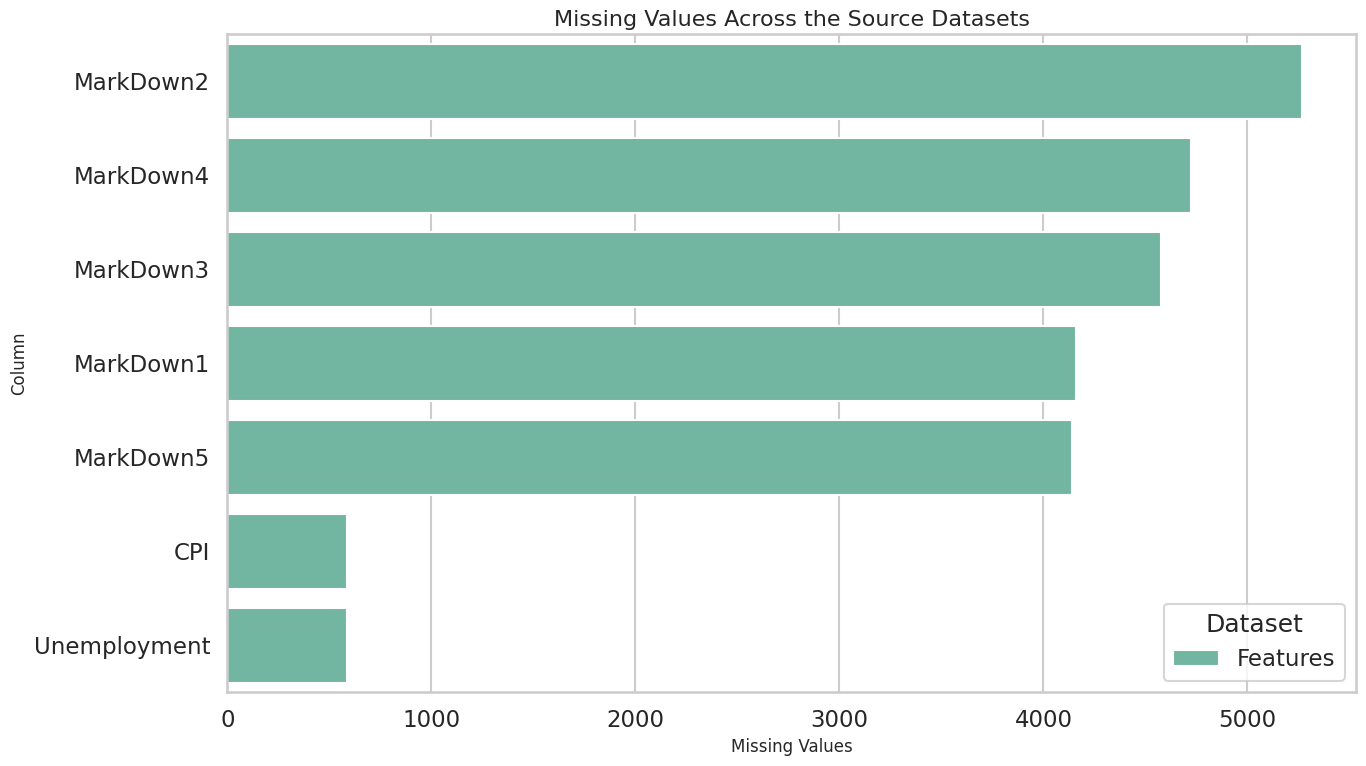

In [9]:
# Code Cell 08: Visualize the missing-value counts so concentration points stand out quickly.

# Only columns with missing values are kept for plotting.
missing_plot_df = missing_summary_df.loc[missing_summary_df["Missing_Values"] > 0].copy()
plt.figure(figsize=(14, 8))  # A taller figure is used because several markdown columns appear in the features table.

# A horizontal bar chart makes it easy to compare missing counts by column and dataset.
sns.barplot(data=missing_plot_df, x="Missing_Values", y="Column", hue="Dataset", palette="Set2")
plt.title("Missing Values Across the Source Datasets")  # A direct title clarifies the purpose of the plot.
plt.xlabel("Missing Values")  # The x-axis shows the number of missing records.
plt.ylabel("Column")  # The y-axis lists the affected columns.
plt.tight_layout()  # The layout is tightened so labels do not overlap.
plt.show()  # The missing-value chart is rendered in the notebook.
plt.close("all")  # Figures are closed after rendering to keep the notebook execution stable.


### 🤔 What did you know about your dataset?


📌 **Data understanding summary**

At this stage, the dataset has a clear business structure. The sales table captures weekly department-level performance, the features table captures the outside conditions and promotional activity around each store-week, and the stores table explains the physical store profile.

The key learning is that this is not a simple sales table. It is a retail planning dataset. Sales can be compared by store, department, time, holiday status, promotion intensity, and economic conditions. This makes it suitable for several connected tasks: sales trend analysis, anomaly detection, store segmentation, proxy department association rules, and demand forecasting.

The main data risk is not duplication. The main risk is how missing markdowns and a small number of missing economic values are handled. If markdowns are misunderstood, promotions may look weaker or stronger than they really are. If time fields are not prepared correctly, forecasting can become unreliable.


## 🧠 ***2. Understanding Your Variables***


In [10]:
# Code Cell 09: Check columns present in each dataset.

# Compare column names across all three source tables.
columns_summary_df = pd.DataFrame(
    {
        'Sales Columns': pd.Series(sales_df.columns),
        'Features Columns': pd.Series(features_df.columns),
        'Stores Columns': pd.Series(stores_df.columns),
    }
)

# Display column list.
display(columns_summary_df)


,Sales Columns,Features Columns,Stores Columns
0,Store,Store,Store
1,Dept,Date,Type
2,Date,Temperature,Size
3,Weekly_Sales,Fuel_Price,NaN
4,IsHoliday,MarkDown1,NaN
5,NaN,MarkDown2,NaN
6,NaN,MarkDown3,NaN
7,NaN,MarkDown4,NaN
8,NaN,MarkDown5,NaN
9,NaN,CPI,NaN


In [11]:
# Code Cell 10: Describe the numeric variables in each source dataset.
display(Markdown("#### Sales Dataset Numeric Summary"))  # A heading keeps the three summary tables visually separate.
display(sales_df.describe(include=[np.number]).T)  # The sales numeric summary helps review scale and dispersion.
display(Markdown("#### Features Dataset Numeric Summary"))  # A heading introduces the feature summary.

# The feature numeric summary highlights markdown and economic ranges.
display(features_df.describe(include=[np.number]).T)
display(Markdown("#### Stores Dataset Numeric Summary"))  # A heading introduces the store summary.

# The store numeric summary shows store identifiers and size distribution.
display(stores_df.describe(include=[np.number]).T)


#### Sales Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,"421,570.00",22.20,12.79,1.00,11.00,22.00,33.00,45.00
Dept,"421,570.00",44.26,30.49,1.00,18.00,37.00,74.00,99.00
Weekly_Sales,"421,570.00","15,981.26","22,711.18","-4,988.94","2,079.65","7,612.03","20,205.85","693,099.36"


#### Features Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,"8,190.00",23.00,12.99,1.00,12.00,23.00,34.00,45.00
Temperature,"8,190.00",59.36,18.68,-7.29,45.90,60.71,73.88,101.95
Fuel_Price,"8,190.00",3.41,0.43,2.47,3.04,3.51,3.74,4.47
MarkDown1,"4,032.00","7,032.37","9,262.75","-2,781.45","1,577.53","4,743.58","8,923.31","103,184.98"
MarkDown2,"2,921.00","3,384.18","8,793.58",-265.76,68.88,364.57,"2,153.35","104,519.54"
MarkDown3,"3,613.00","1,760.10","11,276.46",-179.26,6.60,36.26,163.15,"149,483.31"
MarkDown4,"3,464.00","3,292.94","6,792.33",0.22,304.69,"1,176.42","3,310.01","67,474.85"
MarkDown5,"4,050.00","4,132.22","13,086.69",-185.17,"1,440.83","2,727.14","4,832.56","771,448.10"
CPI,"7,605.00",172.46,39.74,126.06,132.36,182.76,213.93,228.98
Unemployment,"7,605.00",7.83,1.88,3.68,6.63,7.81,8.57,14.31


#### Stores Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,45.00,23.00,13.13,1.00,12.00,23.00,34.00,45.00
Size,45.00,"130,287.60","63,825.27","34,875.00","70,713.00","126,512.00","202,307.00","219,622.00"


### 📝 Variables Description


📚 **How the variables fit together**

The variables can be read as four business blocks:

- **Sales identity:** `Store`, `Dept`, and `Date` tell us where and when the sale happened.
- **Sales outcome:** `Weekly_Sales` tells us the value generated by that store-department-week.
- **Store profile:** `Type` and `Size` describe the kind of store. These help explain why some stores naturally sell more than others.
- **Business conditions:** `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `IsHoliday`, and markdown fields describe the weekly environment around sales.

📌 **Business meaning**

These variables are useful because they combine demand, store characteristics, promotion activity, and external conditions. That combination is exactly what a retail planning team needs for segmentation and forecasting.


### 🔢 Check Unique Values for each variable


In [12]:
# Code Cell 11: Check the number of unique values for each column in the source datasets.

# Sales uniqueness counts are summarized into a table.
sales_unique_df = sales_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
sales_unique_df["Dataset"] = "Sales"  # The source dataset is added for clear identification.

# Feature uniqueness counts are summarized in the same format.
features_unique_df = features_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
features_unique_df["Dataset"] = "Features"  # The source dataset label is attached.

# Store uniqueness counts are summarized in the same format.
stores_unique_df = stores_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
stores_unique_df["Dataset"] = "Stores"  # The source dataset label is attached.

# The three uniqueness tables are stacked together.
unique_summary_df = pd.concat([sales_unique_df, features_unique_df, stores_unique_df], ignore_index=True)
display(unique_summary_df)


,Column,Unique_Values,Dataset
0,Store,45,Sales
1,Dept,81,Sales
2,Date,143,Sales
3,Weekly_Sales,359464,Sales
4,IsHoliday,2,Sales
5,Store,45,Features
6,Date,182,Features
7,Temperature,4178,Features
8,Fuel_Price,1011,Features
9,MarkDown1,4024,Features


## 🛠️ ***3. Data Wrangling***


### 💻 Data Wrangling Code


In [13]:
# Code Cell 12: Merge the datasets, clean the main fields, and build analysis-ready weekly and store-level tables.

# Project folders used later while saving outputs.
PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization')
DATA_DIR = PROJECT_ROOT / 'dateset'
OUTPUT_DIR = PROJECT_ROOT / 'colab_outputs'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Convert date columns before merging and time-based analysis.
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d/%m/%Y')
features_df['Date'] = pd.to_datetime(features_df['Date'], format='%d/%m/%Y')

# Convert holiday flags into clean boolean values.
sales_df['IsHoliday'] = sales_df['IsHoliday'].astype(bool)
features_df['IsHoliday'] = features_df['IsHoliday'].astype(bool)

# Sort records so later time-based logic stays stable.
sales_df = sales_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
features_df = features_df.sort_values(['Store', 'Date']).reset_index(drop=True)
stores_df = stores_df.sort_values(['Store']).reset_index(drop=True)

# Markdown columns are grouped because they are handled together in cleaning and feature creation.
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

# Economic context columns are grouped so missing values can be filled consistently by store.
economic_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
]

# Sales records are joined with weekly feature data using store and date as common keys.
merged_df = sales_df.merge(
    features_df,
    on=["Store", "Date"],
    how="left",
    suffixes=("_sales", "_feature"),
)

# Store attributes are added after the sales-feature merge.
merged_df = merged_df.merge(stores_df, on="Store", how="left")

# Holiday flags from both tables are combined into one final holiday column.
merged_df["IsHoliday"] = (
    merged_df["IsHoliday_sales"].fillna(False)
    | merged_df["IsHoliday_feature"].fillna(False)
)

# Temporary holiday columns are removed after the final flag is created.
merged_df = merged_df.drop(columns=["IsHoliday_sales", "IsHoliday_feature"])
merged_df[markdown_columns] = merged_df[markdown_columns].fillna(0.0)

# Economic values are filled within each store to avoid mixing store-level patterns.
for column_name in economic_columns:
    merged_df[column_name] = merged_df.groupby("Store")[column_name].transform(
        lambda series: series.ffill().bfill()
    )

# Negative sales are capped at zero because final sales should not go below zero.
merged_df["Weekly_Sales_Clean"] = merged_df["Weekly_Sales"].clip(lower=0.0)
merged_df["Year"] = merged_df["Date"].dt.year
merged_df["Month"] = merged_df["Date"].dt.month
merged_df["Quarter"] = merged_df["Date"].dt.quarter
merged_df["WeekOfYear"] = merged_df["Date"].dt.isocalendar().week.astype(int)
merged_df["Holiday_Week"] = merged_df["IsHoliday"].astype(int)
merged_df["Total_MarkDown"] = merged_df[markdown_columns].sum(axis=1)

merged_df = merged_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Weekly totals are created for the forecasting part of the project.
weekly_df = merged_df.groupby("Date", as_index=False).agg(
    Weekly_Sales=("Weekly_Sales_Clean", "sum"),
    Holiday_Week=("Holiday_Week", "max"),
    Mean_Temperature=("Temperature", "mean"),
    Mean_Fuel_Price=("Fuel_Price", "mean"),
    Mean_CPI=("CPI", "mean"),
    Mean_Unemployment=("Unemployment", "mean"),
    Mean_Total_MarkDown=("Total_MarkDown", "mean"),
    Store_Count=("Store", "nunique"),
    Department_Count=("Dept", "nunique"),
)

weekly_df["Year"] = weekly_df["Date"].dt.year
weekly_df["Month"] = weekly_df["Date"].dt.month
weekly_df["Quarter"] = weekly_df["Date"].dt.quarter
weekly_df["WeekOfYear"] = weekly_df["Date"].dt.isocalendar().week.astype(int)
weekly_df["Time_Index"] = np.arange(len(weekly_df))

# Holiday sales averages are calculated separately for later store profiling.
holiday_store_sales_df = (
    merged_df.loc[merged_df["Holiday_Week"] == 1]
    .groupby("Store", as_index=False)["Weekly_Sales_Clean"]
    .mean()
    .rename(columns={"Weekly_Sales_Clean": "Holiday_Sales_Mean"})
)

# Store-level profiles summarize behavior across the full available history.
store_profiles = merged_df.groupby(["Store", "Type", "Size"], as_index=False).agg(
    Mean_Weekly_Sales=("Weekly_Sales_Clean", "mean"),
    Median_Weekly_Sales=("Weekly_Sales_Clean", "median"),
    Sales_Volatility=("Weekly_Sales_Clean", "std"),
    Markdown_Intensity=("Total_MarkDown", "mean"),
    Mean_Temperature=("Temperature", "mean"),
    Mean_Fuel_Price=("Fuel_Price", "mean"),
    Mean_CPI=("CPI", "mean"),
    Mean_Unemployment=("Unemployment", "mean"),
    Department_Count=("Dept", "nunique"),
)

store_profiles = store_profiles.merge(
    holiday_store_sales_df,
    on="Store",
    how="left",
)

store_profiles["Holiday_Sales_Mean"] = store_profiles["Holiday_Sales_Mean"].fillna(
    store_profiles["Mean_Weekly_Sales"]
)
store_profiles["Sales_Volatility"] = store_profiles["Sales_Volatility"].fillna(0.0)

# A short summary confirms the prepared tables before moving forward.
wrangling_summary_df = pd.DataFrame(
    {
        "Prepared Table": [
            "Merged Detail Table",
            "Weekly Forecast Table",
            "Store Profile Table",
        ],
        "Rows": [
            merged_df.shape[0],
            weekly_df.shape[0],
            store_profiles.shape[0],
        ],
        "Columns": [
            merged_df.shape[1],
            weekly_df.shape[1],
            store_profiles.shape[1],
        ],
    }
)

display(wrangling_summary_df)
display(weekly_df.head())
display(store_profiles.head())


,Prepared Table,Rows,Columns
0,Merged Detail Table,421570,23
1,Weekly Forecast Table,143,15
2,Store Profile Table,45,13


,Date,Weekly_Sales,Holiday_Week,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Mean_Total_MarkDown,Store_Count,Department_Count,Year,Month,Quarter,WeekOfYear,Time_Index
0,2010-02-05,"49,750,875.98",0,33.28,2.72,167.40,8.58,0.00,45,78,2010,2,1,5,0
1,2010-02-12,"48,336,800.10",1,33.36,2.70,167.38,8.57,0.00,45,79,2010,2,1,6,1
2,2010-02-19,"48,277,902.33",0,37.04,2.67,167.34,8.58,0.00,45,79,2010,2,1,7,2
3,2010-02-26,"43,970,440.65",0,38.63,2.69,167.69,8.56,0.00,45,78,2010,2,1,8,3
4,2010-03-05,"46,872,715.16",0,42.37,2.73,167.73,8.57,0.00,45,79,2010,3,1,9,4


,Store,Type,Size,Mean_Weekly_Sales,Median_Weekly_Sales,Sales_Volatility,Markdown_Intensity,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Department_Count,Holiday_Sales_Mean
0,1,A,151315,"21,710.93","10,289.38","27,748.64","7,331.80",68.22,3.22,216.00,7.61,77,"23,039.39"
1,2,A,202307,"26,898.53","14,333.53","33,077.23","10,039.57",68.11,3.22,215.65,7.62,78,"28,799.05"
2,3,B,37392,"6,373.17","2,804.82","14,250.97","2,460.90",71.30,3.22,219.40,7.18,72,"6,916.45"
3,4,A,205863,"29,161.34","15,116.81","34,583.57","9,698.51",62.18,3.22,128.68,5.97,78,"30,854.23"
4,5,B,34875,"5,053.46","2,582.66","8,068.19","2,924.78",69.20,3.22,216.58,6.30,72,"5,617.26"


### 💡 What manipulations have you done and insights found?


🛠️ **Reading the output**

The wrangling step creates three important analysis views:

- **Merged Detail Table:** **421,570 rows** and **23 columns**. This keeps the original store-department-week detail after joining sales, features, and store attributes.
- **Weekly Forecast Table:** **143 rows**. This aggregates the data into total weekly sales, which is useful for overall demand forecasting.
- **Store Profile Table:** **45 rows**. This summarizes each store, which is useful for segmentation.

📌 **Business meaning**

The row count of the merged detail table remains the same as the sales table, so the merge did not accidentally multiply records. That is important. The weekly table gives a high-level demand view, while the store profile table gives a store comparison view. These three levels together support detailed analysis, strategic forecasting, and store segmentation.


## 📈 ***4. Data Visualization, Storytelling & Experimenting with charts***


#### Chart - 1 | Weekly Total Sales Trend


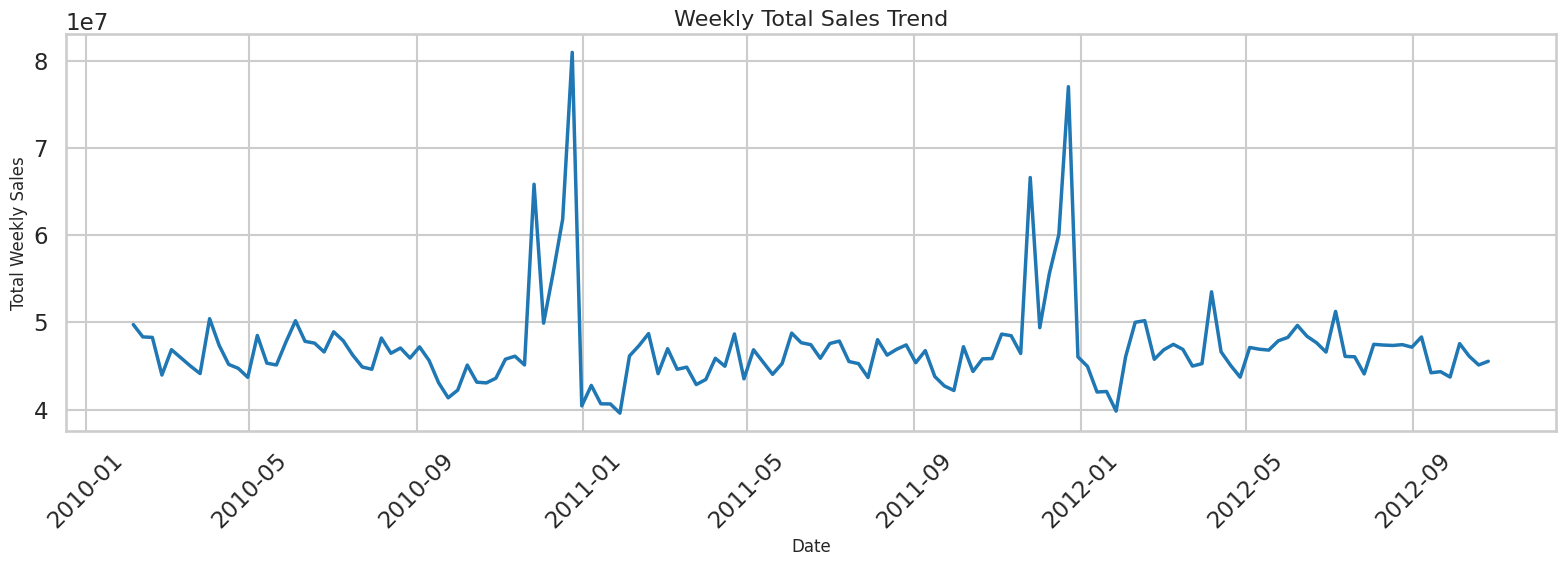

In [14]:
# Code Cell 13: Plot the weekly total sales trend across the full time span.
plt.figure(figsize=(16, 6))  # A wider figure helps show the weekly trend clearly across multiple years.

# The line plot highlights demand movement across time.
sns.lineplot(data=weekly_df, x="Date", y="Weekly_Sales", color="#1f77b4", linewidth=2.5)
plt.title("Weekly Total Sales Trend")  # The title states exactly what the chart shows.
plt.xlabel("Date")  # The x-axis uses time because this is the central forecasting view.
plt.ylabel("Total Weekly Sales")  # The y-axis shows sales in original business units.
plt.xticks(rotation=45)  # Rotated dates remain easier to read on a dense weekly axis.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weekly_total_sales_trend.png", dpi=150, bbox_inches="tight")  # The layout is tightened so labels fit comfortably.
plt.show()  # The time-series chart is rendered in the notebook.
plt.close("all")  # Figures are closed after display to keep execution stable.


##### 1. Why did you pick the specific chart?


📈 A line chart is used because weekly sales are time-based. It lets us see trend, seasonality, and sudden movement in one continuous view.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Weekly sales move in a clear seasonal pattern instead of staying flat. The largest visible spike occurs around late December, with the highest weekly total reaching about **80.9 million** on **2010-12-24**. There are also strong spikes around late November and December in both 2010 and 2011, which matches holiday shopping behavior.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** This tells the business that year-end demand should not be planned like a normal week. Inventory, staffing, and promotion calendars need extra attention around November and December.


#### Chart - 2 | Holiday vs Non-Holiday Sales


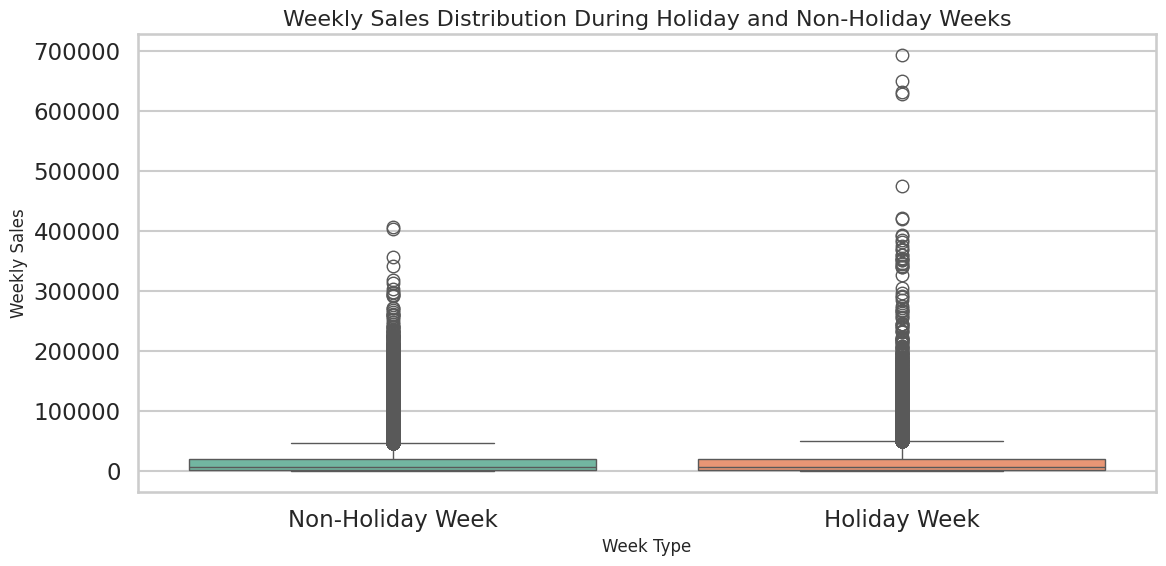

In [15]:
# Code Cell 14: Compare holiday and non-holiday weekly sales with a box plot.

# A compact comparison frame is created for plotting.
holiday_sales_view_df = merged_df[["Weekly_Sales_Clean", "IsHoliday"]].copy()

# Readable category labels are created for the box plot.
holiday_sales_view_df["Holiday_Label"] = np.where(holiday_sales_view_df["IsHoliday"], "Holiday Week", "Non-Holiday Week")
plt.figure(figsize=(12, 6))  # A medium figure is enough because only two categories are being compared.

# The box plot compares spread, median, and extreme values across the two groups.
sns.boxplot(data=holiday_sales_view_df, x="Holiday_Label", y="Weekly_Sales_Clean", palette="Set2")

# The title explains the comparison directly.
plt.title("Weekly Sales Distribution During Holiday and Non-Holiday Weeks")
plt.xlabel("Week Type")  # The x-axis identifies the two comparison groups.
plt.ylabel("Weekly Sales")  # The y-axis shows the target distribution.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "holiday_vs_nonholiday_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened to keep labels neat.
plt.show()  # The comparison chart is rendered in the notebook.
plt.close("all")  # Figures are closed after display to avoid build-up during execution.


##### 1. Why did you pick the specific chart?


📦 A box plot is used because it compares the center, spread, and extreme values of holiday and non-holiday sales in one view.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Holiday weeks show higher average sales than non-holiday weeks. The average weekly sales per record is about **17,036** during holiday weeks compared with about **15,902** during non-holiday weeks. Holiday weeks also have wider spread, meaning they are not only higher on average but also more variable.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Holiday weeks need separate planning rules. A normal-week forecast or stock level may underprepare the store during holiday demand peaks.


#### Chart - 3 | Average Sales by Store Type


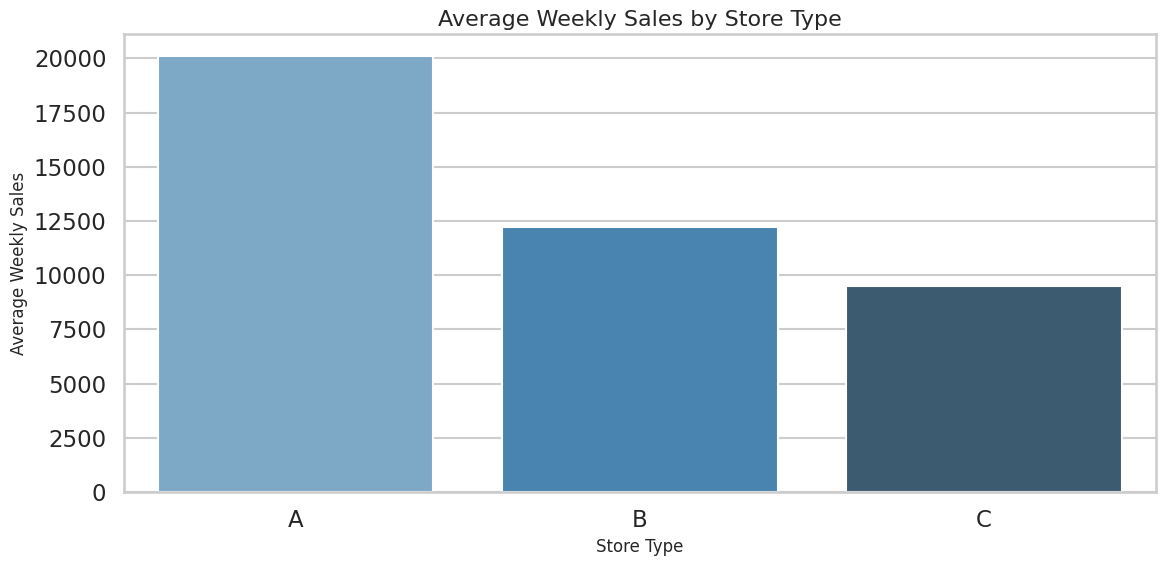

In [16]:
# Code Cell 15: Plot the average weekly sales by store type.

# Average sales are calculated for each store type.
store_type_sales_df = merged_df.groupby("Type", as_index=False)["Weekly_Sales_Clean"].mean().sort_values("Weekly_Sales_Clean", ascending=False)
plt.figure(figsize=(12, 6))  # A simple bar chart fits well because the number of store types is small.

# A ranked bar chart makes the store-type comparison easy to read.
sns.barplot(data=store_type_sales_df, x="Type", y="Weekly_Sales_Clean", palette="Blues_d")
plt.title("Average Weekly Sales by Store Type")  # The title clarifies the business comparison.
plt.xlabel("Store Type")  # The x-axis lists the nominal store categories.
plt.ylabel("Average Weekly Sales")  # The y-axis shows the average sales level.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "average_sales_by_store_type.png", dpi=150, bbox_inches="tight")  # The layout is tightened so the bar labels remain readable.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


🏬 A bar chart is suitable because store type is a category, and the output needs a direct comparison across Type A, B, and C stores.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Type A stores have the highest average weekly sales, followed by Type B and then Type C. The average sales levels are roughly **20,100** for Type A, **12,237** for Type B, and **9,520** for Type C.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Store type is a meaningful business divider. Larger or stronger store formats should not be planned with the same sales expectations as smaller formats.


#### Chart - 4 | Top Stores by Total Sales


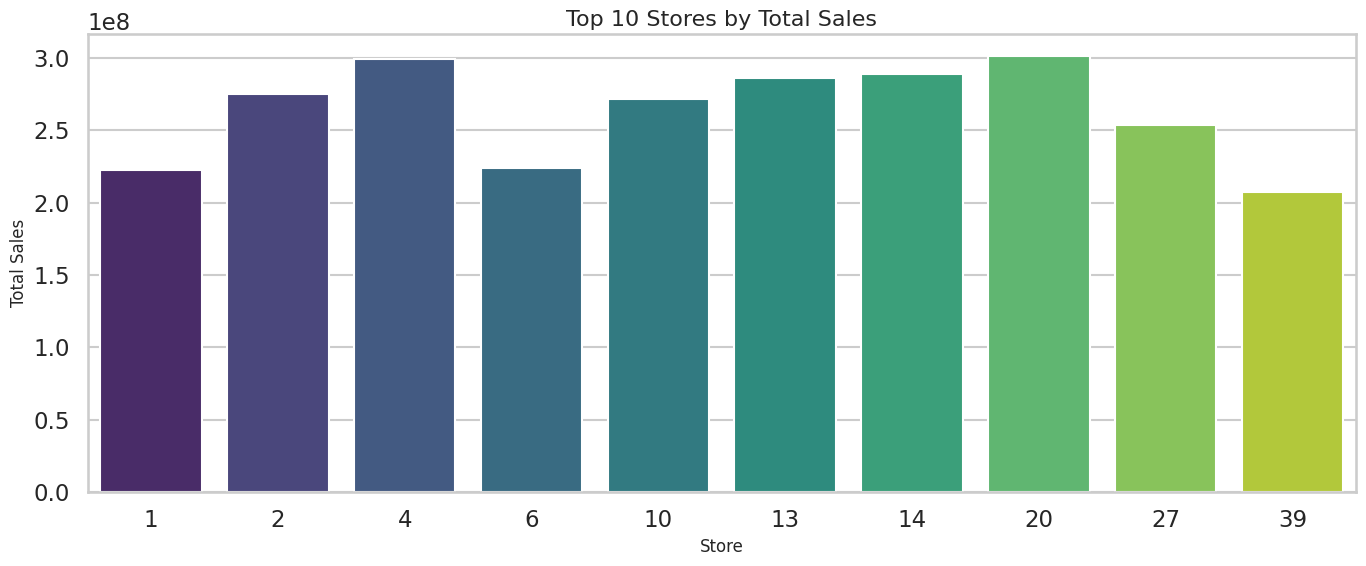

In [17]:
# Code Cell 16: Plot the stores with the highest total sales contribution.

# The ten highest-contributing stores are selected for a focused comparison.
top_store_sales_df = merged_df.groupby("Store", as_index=False)["Weekly_Sales_Clean"].sum().sort_values("Weekly_Sales_Clean", ascending=False).head(10)
plt.figure(figsize=(14, 6))  # A wider figure gives the ranked stores enough room on the x-axis.

# A ranked bar chart makes contribution differences easy to compare.
sns.barplot(data=top_store_sales_df, x="Store", y="Weekly_Sales_Clean", palette="viridis")
plt.title("Top 10 Stores by Total Sales")  # The title explains the ranking directly.
plt.xlabel("Store")  # The x-axis lists the store identifiers.
plt.ylabel("Total Sales")  # The y-axis shows cumulative sales contribution.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_10_stores_by_total_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened so the chart remains tidy.
plt.show()  # The top-store chart is rendered.
plt.close("all")


##### 1. Why did you pick the specific chart?


🏆 A ranked bar chart is used because it quickly shows which stores contribute the most revenue.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Store **20** is the highest contributor, followed closely by Stores **4**, **14**, **13**, and **2**. The top stores are not just slightly ahead; they contribute very large total sales compared with the rest of the network.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** High-contribution stores deserve tighter stock monitoring and stronger service-level protection because mistakes there affect overall revenue more heavily.


#### Chart - 5 | Monthly Sales Seasonality


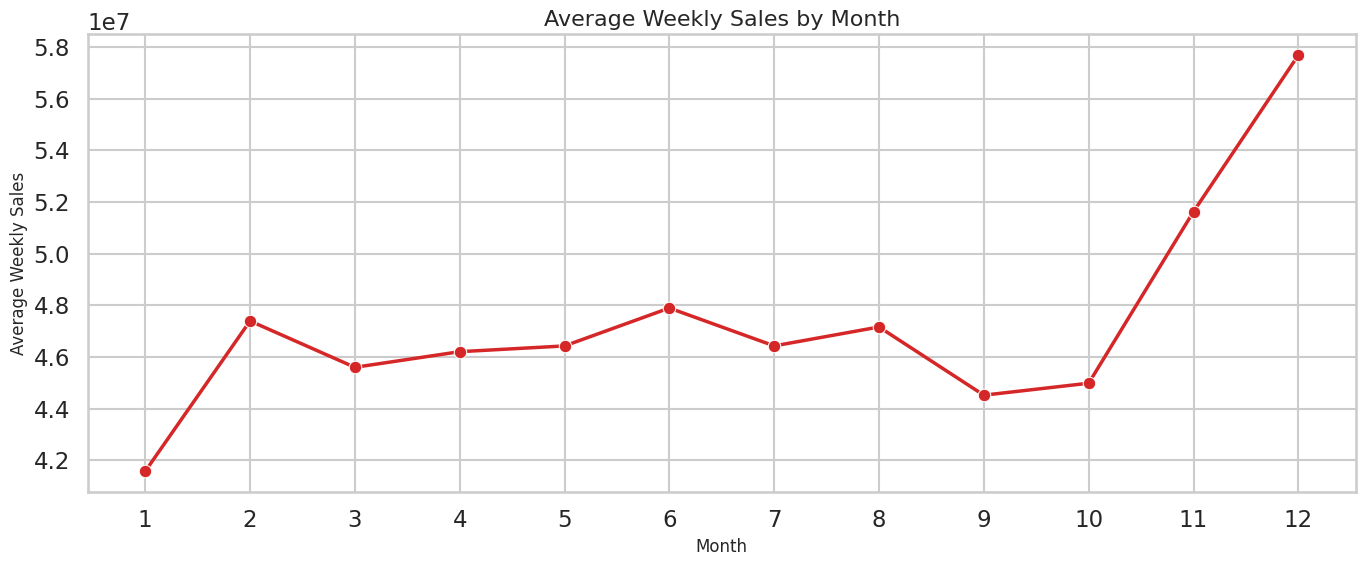

In [18]:
# Code Cell 17: Plot the average total sales by calendar month to inspect seasonality.

# Average weekly sales are grouped by month to highlight seasonal rhythm.
monthly_sales_df = weekly_df.groupby("Month", as_index=False)["Weekly_Sales"].mean()
plt.figure(figsize=(14, 6))  # A medium-wide figure keeps the monthly pattern easy to read.

# A line chart shows how average demand changes through the calendar cycle.
sns.lineplot(data=monthly_sales_df, x="Month", y="Weekly_Sales", marker="o", linewidth=2.5, color="#d62728")
plt.title("Average Weekly Sales by Month")  # The title explains the seasonal focus.
plt.xlabel("Month")  # The x-axis represents calendar month.
plt.ylabel("Average Weekly Sales")  # The y-axis shows the typical demand level.
plt.xticks(ticks=range(1, 13))  # All month numbers are shown for a complete seasonal view.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_sales_seasonality.png", dpi=150, bbox_inches="tight")  # The layout is tightened to keep the figure clean.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


📅 Monthly aggregation is used because seasonality is easier to read by month than by individual weekly points.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

December has the strongest average weekly sales, followed by November. January is the weakest month in the monthly view. This shows that demand rises strongly near the holiday season and cools down after that period.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** The business can prepare seasonal inventory and promotion plans earlier instead of reacting after demand has already increased.


#### Chart - 6 | Temperature vs Sales


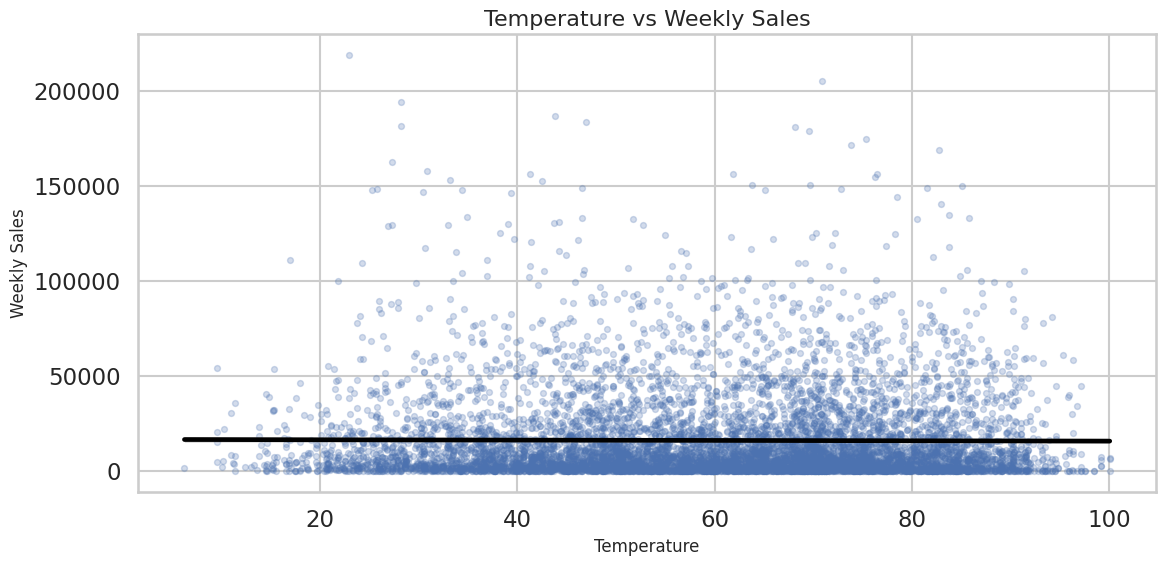

In [19]:
# Code Cell 18: Plot temperature against weekly sales on a manageable sample of records.

# A sample keeps the scatter plot readable and fast without changing the overall pattern much.
temperature_sales_sample_df = merged_df[["Temperature", "Weekly_Sales_Clean"]].dropna().sample(n=min(8000, len(merged_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(12, 6))  # A standard figure size is enough for the sampled scatter view.

# The regression line gives a quick directional view of the relationship.
sns.regplot(data=temperature_sales_sample_df, x="Temperature", y="Weekly_Sales_Clean", scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "black"})
plt.title("Temperature vs Weekly Sales")  # The title states the variables being compared.
plt.xlabel("Temperature")  # The x-axis shows temperature values.
plt.ylabel("Weekly Sales")  # The y-axis shows sales values.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "temperature_vs_weekly_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened for clean export.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


🌡️ A scatter plot is used because temperature and sales are both numeric, and the chart can show whether sales move with weather.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

The relationship between temperature and weekly sales is very weak. The correlation is close to zero, slightly negative at about **-0.002** at the detailed row level. This means temperature alone does not explain sales movement well in this dataset.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Temperature can stay as a contextual feature, but it should not be treated as a main sales driver without support from other variables.


#### Chart - 7 | Unemployment vs Sales


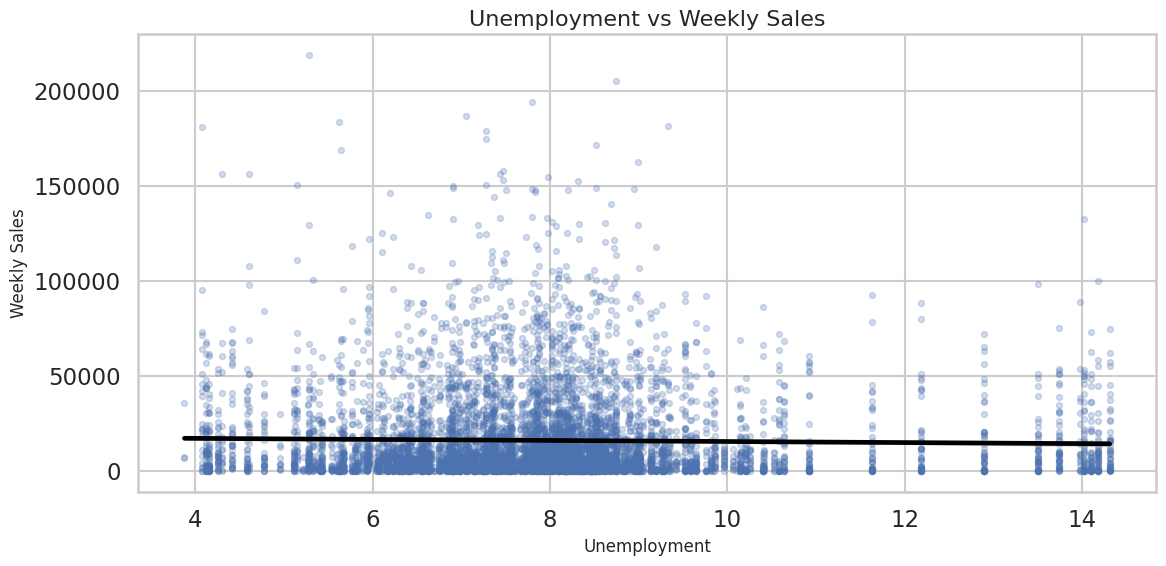

In [20]:
# Code Cell 19: Plot unemployment against weekly sales on a sampled view of the dataset.

# A sample keeps the plot light while preserving the broad pattern.
unemployment_sales_sample_df = merged_df[["Unemployment", "Weekly_Sales_Clean"]].dropna().sample(n=min(8000, len(merged_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(12, 6))  # A standard figure size keeps the scatter readable.

# The regression line gives a quick directional check.
sns.regplot(data=unemployment_sales_sample_df, x="Unemployment", y="Weekly_Sales_Clean", scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "black"})
plt.title("Unemployment vs Weekly Sales")  # The title clarifies the macroeconomic comparison.
plt.xlabel("Unemployment")  # The x-axis represents the unemployment rate.
plt.ylabel("Weekly Sales")  # The y-axis represents weekly sales.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "unemployment_vs_weekly_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened for readability.
plt.show()  # The scatter plot is rendered.
plt.close("all")


##### 1. Why did you pick the specific chart?


📉 A scatter plot is used because unemployment and sales are numeric, and the chart checks whether economic stress appears linked with demand.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

The unemployment-sales relationship is also weak. The detailed correlation is about **-0.026**, which suggests only a slight negative direction. In simple terms, higher unemployment does not strongly explain weekly sales by itself here.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Unemployment is useful as background economic context, but the business should combine it with time, store type, holiday, and promotion signals.


#### Chart - 8 | Markdown Intensity vs Sales


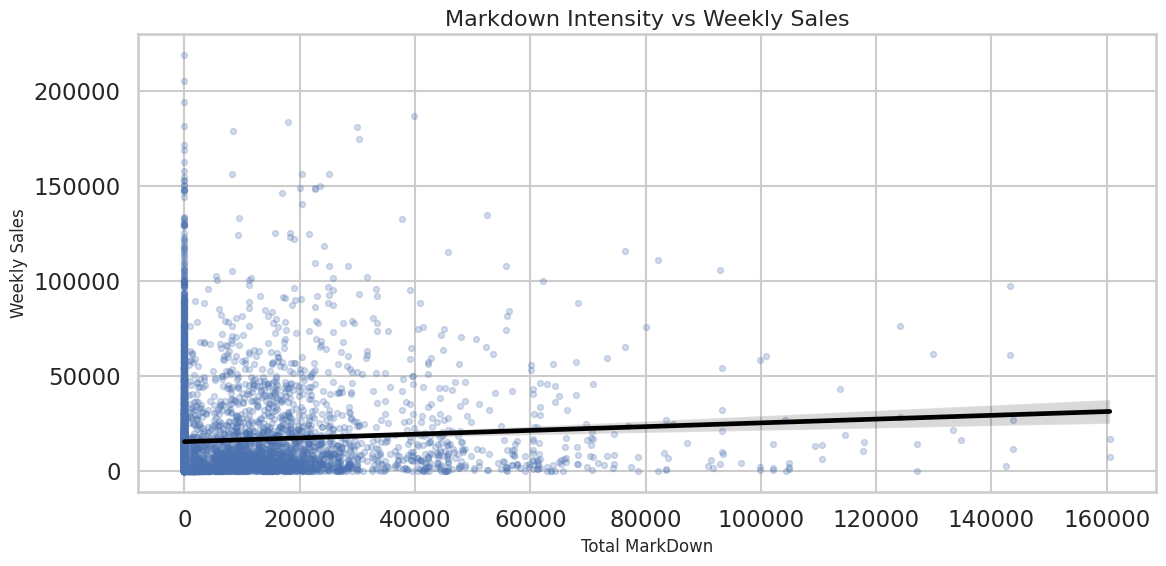

In [21]:
# Code Cell 20: Plot markdown intensity against weekly sales on a sampled view.

# Use a sample so the plot stays responsive.
markdown_sales_sample_df = merged_df[["Total_MarkDown", "Weekly_Sales_Clean"]].dropna().sample(n=min(8000, len(merged_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(12, 6))  # A standard figure size is enough for the sampled scatter plot.

# The regression line provides a quick directional read on markdown effect.
sns.regplot(data=markdown_sales_sample_df, x="Total_MarkDown", y="Weekly_Sales_Clean", scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "black"})
plt.title("Markdown Intensity vs Weekly Sales")  # The title explains the promotion-focused comparison.
plt.xlabel("Total MarkDown")  # The x-axis shows total markdown intensity.
plt.ylabel("Weekly Sales")  # The y-axis shows weekly sales values.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "markdown_intensity_vs_weekly_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened for clean display.
plt.show()  # The scatter plot is rendered.
plt.close("all")


##### 1. Why did you pick the specific chart?


🏷️ A scatter plot is used because markdown intensity and sales are numeric, and the goal is to inspect promotion-sales behavior.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Markdowns show a small positive relationship with sales. The detailed correlation is about **0.065**, so markdowns are connected with demand, but not strongly enough to explain sales alone. This is realistic because promotions work differently by store, department, and season.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Markdown planning should be reviewed with store and department context. A discount by itself does not guarantee a large sales lift.


#### Chart - 9 | Weekly Anomaly Highlights


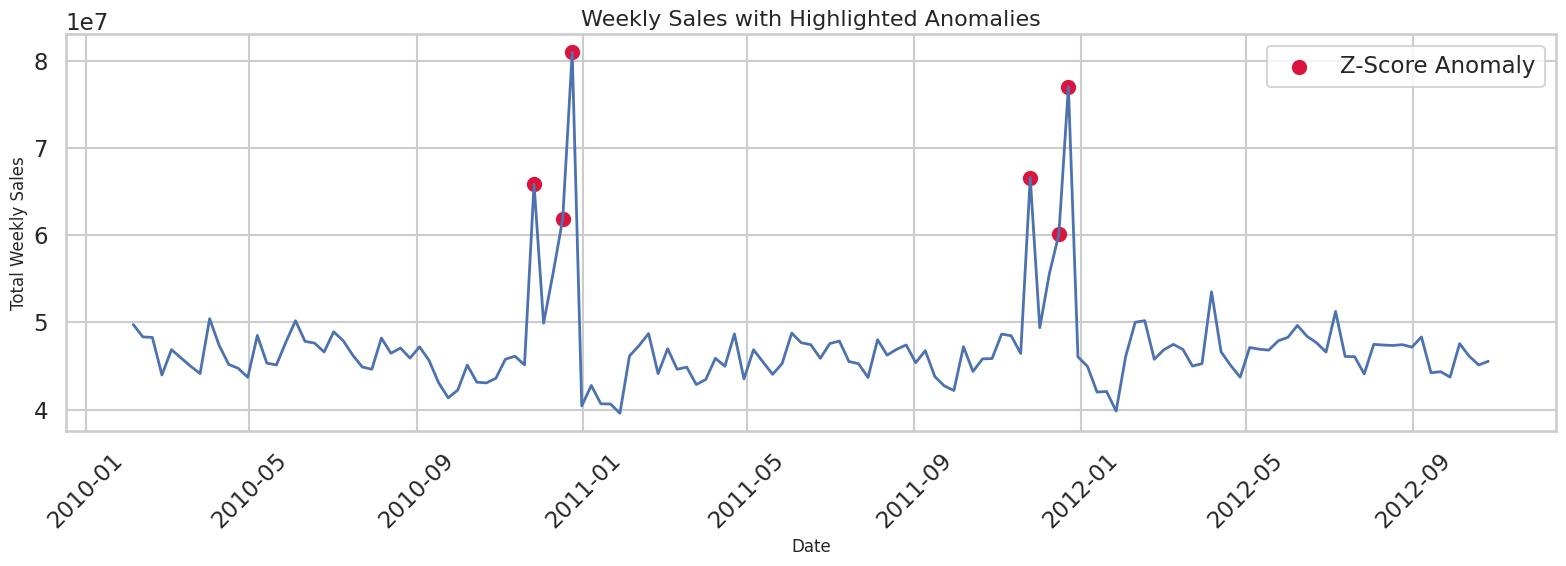

In [22]:
# Code Cell 21: Highlight unusually high or low weekly sales using a z-score rule.

# A z-score is computed so extreme weeks can be flagged relative to the overall sales distribution.
weekly_df["Sales_Z_Score"] = stats.zscore(weekly_df["Weekly_Sales"], nan_policy="omit")

# Weeks beyond two standard deviations are marked as anomalies.
weekly_df["Z_Anomaly_Flag"] = weekly_df["Sales_Z_Score"].abs().gt(2.0).astype(int)

# Only the flagged weeks are isolated for the highlight layer.
anomaly_points_df = weekly_df.loc[weekly_df["Z_Anomaly_Flag"] == 1, ["Date", "Weekly_Sales"]]
plt.figure(figsize=(16, 6))  # A wider figure keeps the weekly time axis readable.

# The full weekly demand path is drawn first.
sns.lineplot(data=weekly_df, x="Date", y="Weekly_Sales", color="#4c72b0", linewidth=2)

# Flagged weeks are overlaid as highlighted points.
plt.scatter(anomaly_points_df["Date"], anomaly_points_df["Weekly_Sales"], color="crimson", s=90, label="Z-Score Anomaly")
plt.title("Weekly Sales with Highlighted Anomalies")  # The title clarifies the purpose of the visual.
plt.xlabel("Date")  # The x-axis stays on calendar time.
plt.ylabel("Total Weekly Sales")  # The y-axis stays on original sales units.
plt.xticks(rotation=45)  # Rotated dates remain readable on the dense time scale.
plt.legend()  # A legend identifies the anomaly markers.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weekly_sales_anomaly_highlights.png", dpi=150, bbox_inches="tight")  # The layout is tightened so dates and labels fit well.
plt.show()  # The anomaly chart is rendered.
plt.close("all")


##### 1. Why did you pick the specific chart?


🚨 A time-based anomaly chart is used because unusual sales weeks make more sense when they are shown on the calendar.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

The highlighted points are **Z-score anomalies**. A Z-score tells how far a week is from the normal weekly sales level. Here, weeks more than about two standard deviations away are flagged. The strongest flagged weeks are around **late November and late December**, including **2010-12-24** and **2011-12-23**. These are not random errors; they look like holiday-season demand spikes.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** These weeks should be reviewed, not blindly removed. They are important for holiday planning, but they can mislead normal-week forecasting if handled carelessly.


#### Chart - 10 | Store Size vs Mean Sales


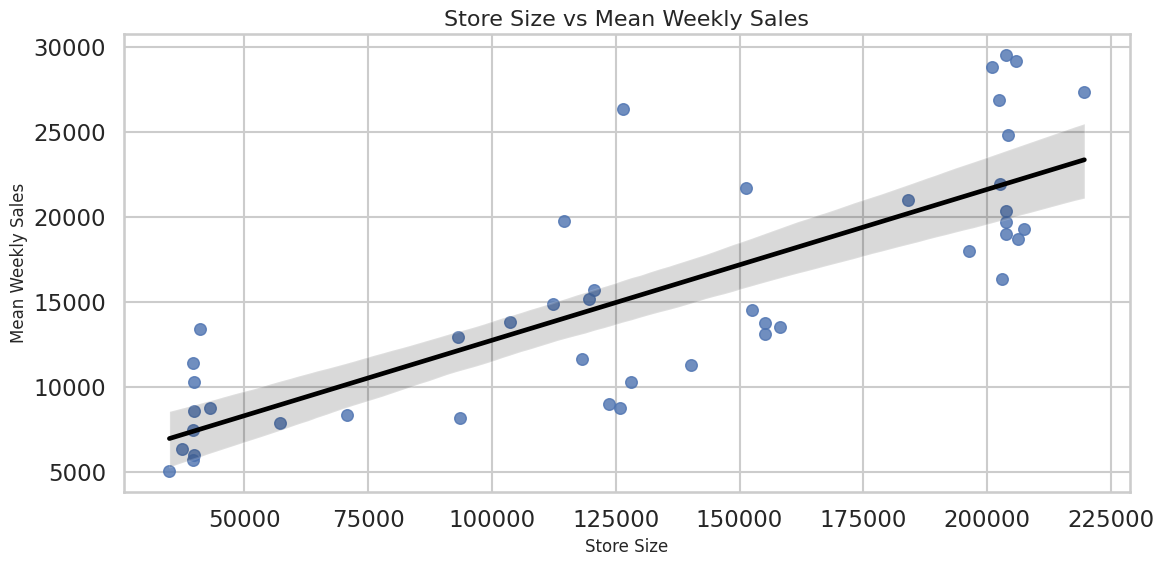

In [23]:
# Code Cell 22: Plot store size against mean weekly sales.
plt.figure(figsize=(12, 6))  # A standard figure size keeps the store profile scatter readable.

# A regression line helps read the direction of association between footprint and sales.
sns.regplot(data=store_profiles, x="Size", y="Mean_Weekly_Sales", scatter_kws={"s": 70, "alpha": 0.8}, line_kws={"color": "black"})
plt.title("Store Size vs Mean Weekly Sales")  # The title describes the store-level comparison directly.
plt.xlabel("Store Size")  # The x-axis represents store size.
plt.ylabel("Mean Weekly Sales")  # The y-axis represents average sales.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "store_size_vs_mean_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened for neat display.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


📐 A scatter plot is used because store size and mean weekly sales are numeric, and the chart checks whether bigger stores sell more.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Store size has a strong positive relationship with mean weekly sales. The store-level correlation is about **0.81**, which means larger stores generally produce higher average sales.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Store size should be included in segmentation because it explains a major part of store performance differences.


#### Chart - 11 | Top Departments by Total Sales


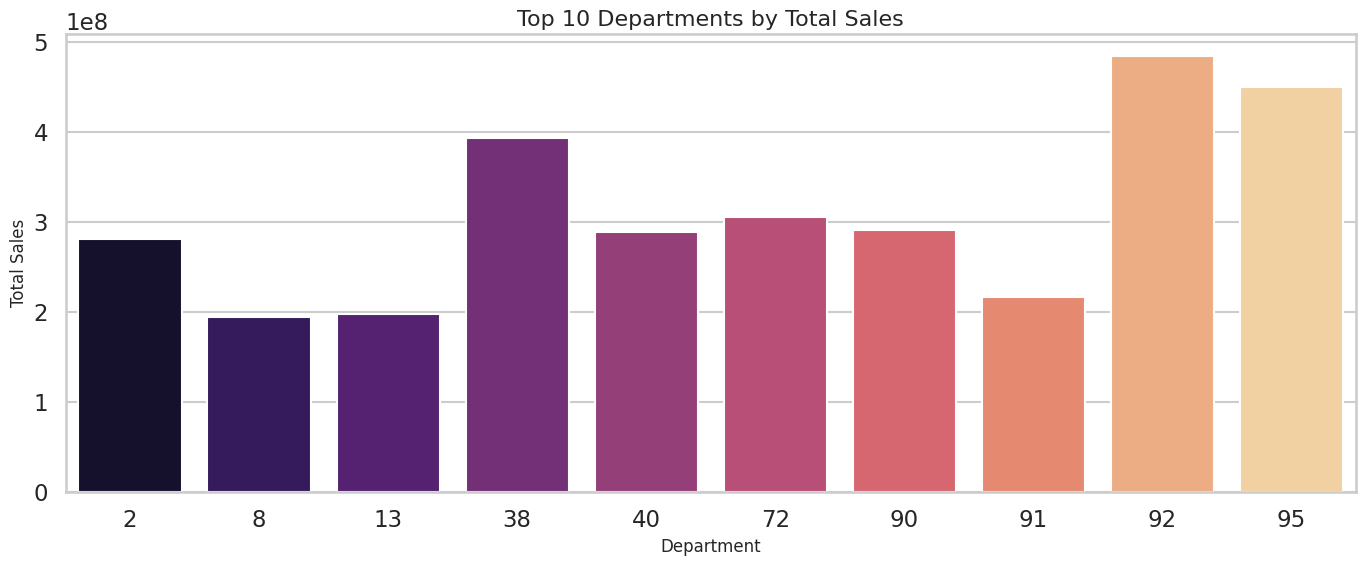

In [24]:
# Code Cell 23: Plot the departments with the highest total sales contribution.

# The ten highest-selling departments are selected for a focused comparison.
top_department_sales_df = merged_df.groupby("Dept", as_index=False)["Weekly_Sales_Clean"].sum().sort_values("Weekly_Sales_Clean", ascending=False).head(10)
plt.figure(figsize=(14, 6))  # A wider figure keeps the ranked department labels readable.

# A ranked bar chart makes department contribution easy to compare.
sns.barplot(data=top_department_sales_df, x="Dept", y="Weekly_Sales_Clean", palette="magma")
plt.title("Top 10 Departments by Total Sales")  # The title states the ranking directly.
plt.xlabel("Department")  # The x-axis lists department identifiers.
plt.ylabel("Total Sales")  # The y-axis shows cumulative sales contribution.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_10_departments_by_total_sales.png", dpi=150, bbox_inches="tight")  # The layout is tightened for a clean chart.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


🏷️ A ranked bar chart is used because it makes the highest-selling departments easy to identify.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Department **92** is the largest sales contributor, followed by Departments **95**, **38**, **72**, and **90**. These departments form the strongest revenue areas in the data.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** High-performing departments should receive careful replenishment planning, because stockouts in these departments can directly hurt total sales.


#### Chart - 12 | Store Sales Volatility Distribution


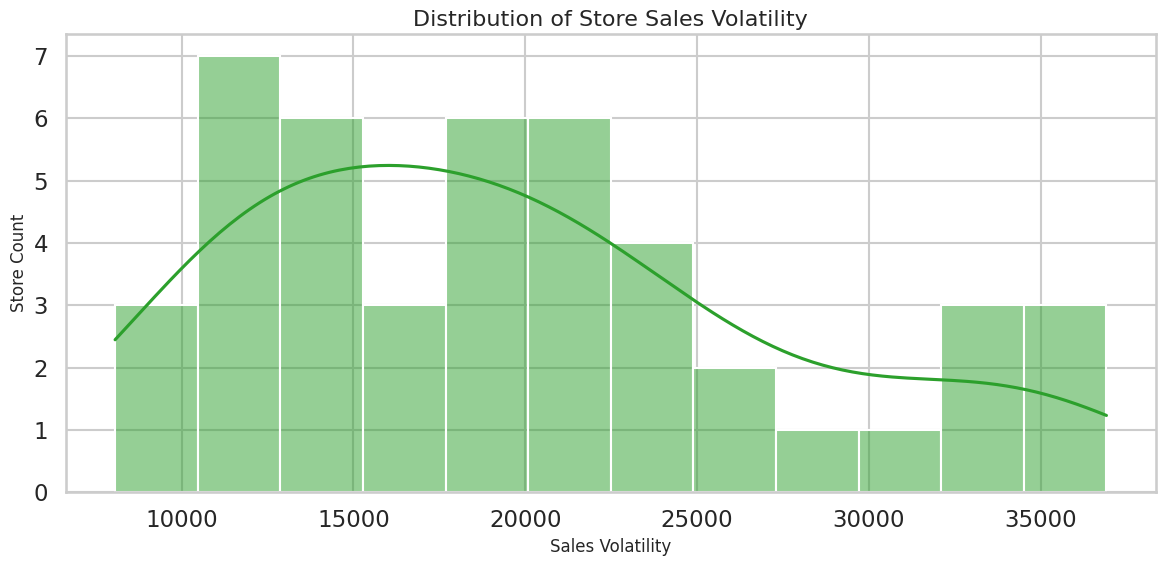

In [25]:
# Code Cell 24: Visualize the distribution of store-level sales volatility.
plt.figure(figsize=(12, 6))  # A standard figure size works well for the volatility histogram.

# The histogram shows how volatility is distributed across stores.
sns.histplot(store_profiles["Sales_Volatility"], bins=12, kde=True, color="#2ca02c")
plt.title("Distribution of Store Sales Volatility")  # The title explains the operational focus of the chart.
plt.xlabel("Sales Volatility")  # The x-axis shows the volatility measure.
plt.ylabel("Store Count")  # The y-axis shows how many stores fall into each volatility band.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "store_sales_volatility_distribution.png", dpi=150, bbox_inches="tight")  # The layout is tightened for cleaner output.
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


📊 A histogram is used because it shows how sales volatility is spread across stores.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Store volatility is not equal across the network. The median volatility is around **18,312**, while the highest store volatility is about **36,911**. This means some stores have much more unstable weekly demand than others.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** High-volatility stores need stronger monitoring and more flexible inventory buffers than stable stores.


#### Chart - 13 | Quarterly Sales Distribution


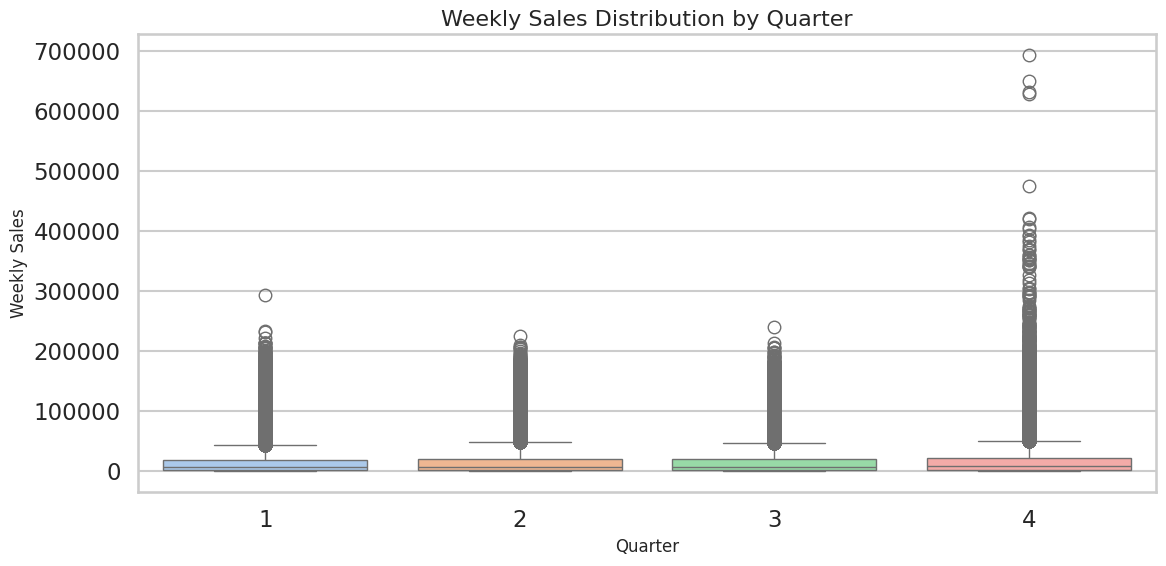

In [26]:
# Code Cell 25: Compare weekly sales distribution across quarters.
plt.figure(figsize=(12, 6))  # A standard figure size is enough for a quarter-wise box plot.

# A quarter-wise box plot shows level and spread differences across seasonal phases.
sns.boxplot(data=merged_df, x="Quarter", y="Weekly_Sales_Clean", palette="pastel")
plt.title("Weekly Sales Distribution by Quarter")  # The title describes the seasonal comparison directly.
plt.xlabel("Quarter")  # The x-axis lists the quarter categories.
plt.ylabel("Weekly Sales")  # The y-axis shows weekly sales distribution.
plt.tight_layout()
plt.savefig(FIGURE_DIR / "quarterly_sales_distribution.png", dpi=150, bbox_inches="tight")  # The layout is tightened for readability.
plt.show()  # The quarter comparison chart is rendered.
plt.close("all")


##### 1. Why did you pick the specific chart?


📆 A quarterly box plot is used because it compares seasonal phases at a broader business level.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

Quarter 4 has the highest average weekly sales and the widest spread. This matches the monthly and anomaly views, where year-end holiday demand creates stronger and more variable sales behavior.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


💼 **Business use:** Quarter 4 should be treated as a special planning period for inventory, staffing, promotions, and anomaly interpretation.


#### Chart - 14 - Correlation Heatmap


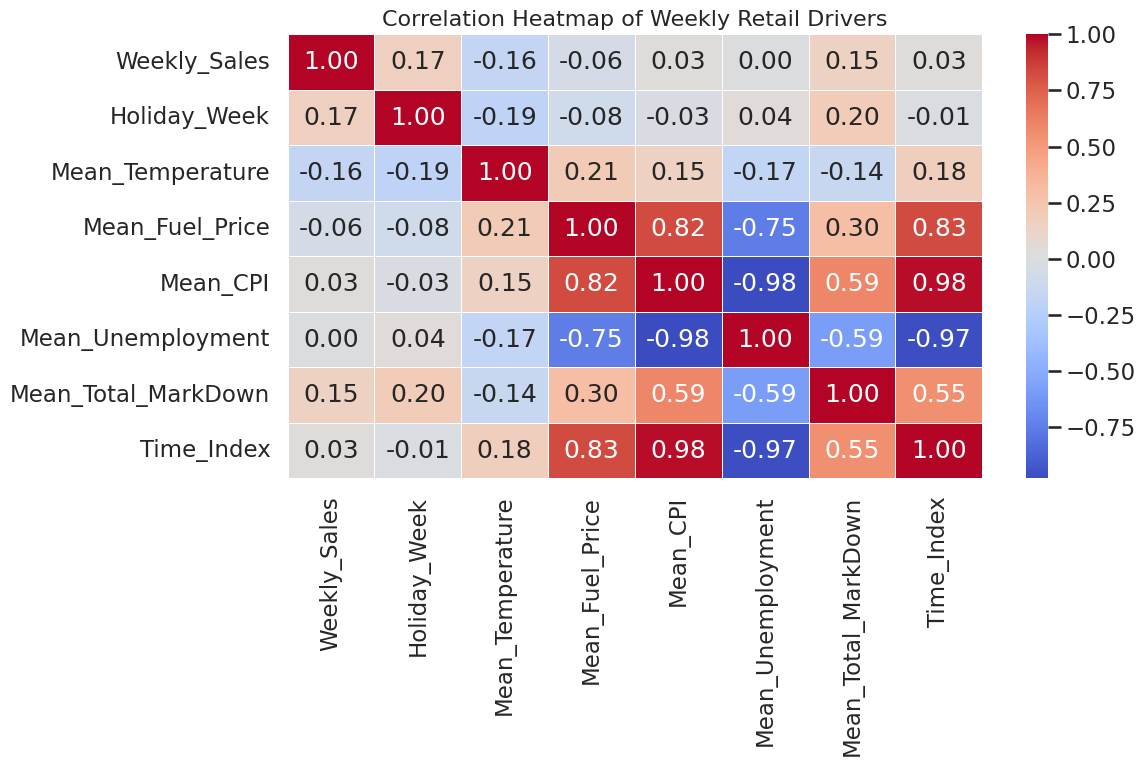

In [27]:
# Code Cell 26: Plot a correlation heatmap for the main numeric variables.

# Select weekly numeric fields that are useful for correlation analysis.
correlation_columns = [
    "Weekly_Sales",
    "Holiday_Week",
    "Mean_Temperature",
    "Mean_Fuel_Price",
    "Mean_CPI",
    "Mean_Unemployment",
    "Mean_Total_MarkDown",
    "Time_Index",
]

# Build the correlation matrix.
correlation_matrix = weekly_df[correlation_columns].corr()

# Plot the heatmap.
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Weekly Retail Drivers")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmap_weekly_drivers.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?


🧭 A heatmap is used because it summarizes relationships between weekly sales and multiple business drivers in one compact view.


##### 2. What is/are the insight(s) found from the chart?


🔎 **Insight from the chart**

At the weekly level, sales show a positive relationship with holiday weeks and markdown activity, while temperature has a clearer negative relationship than it did at row level. This means broad weekly demand behaves differently from individual store-department rows.


#### Chart - 15 - Pair Plot


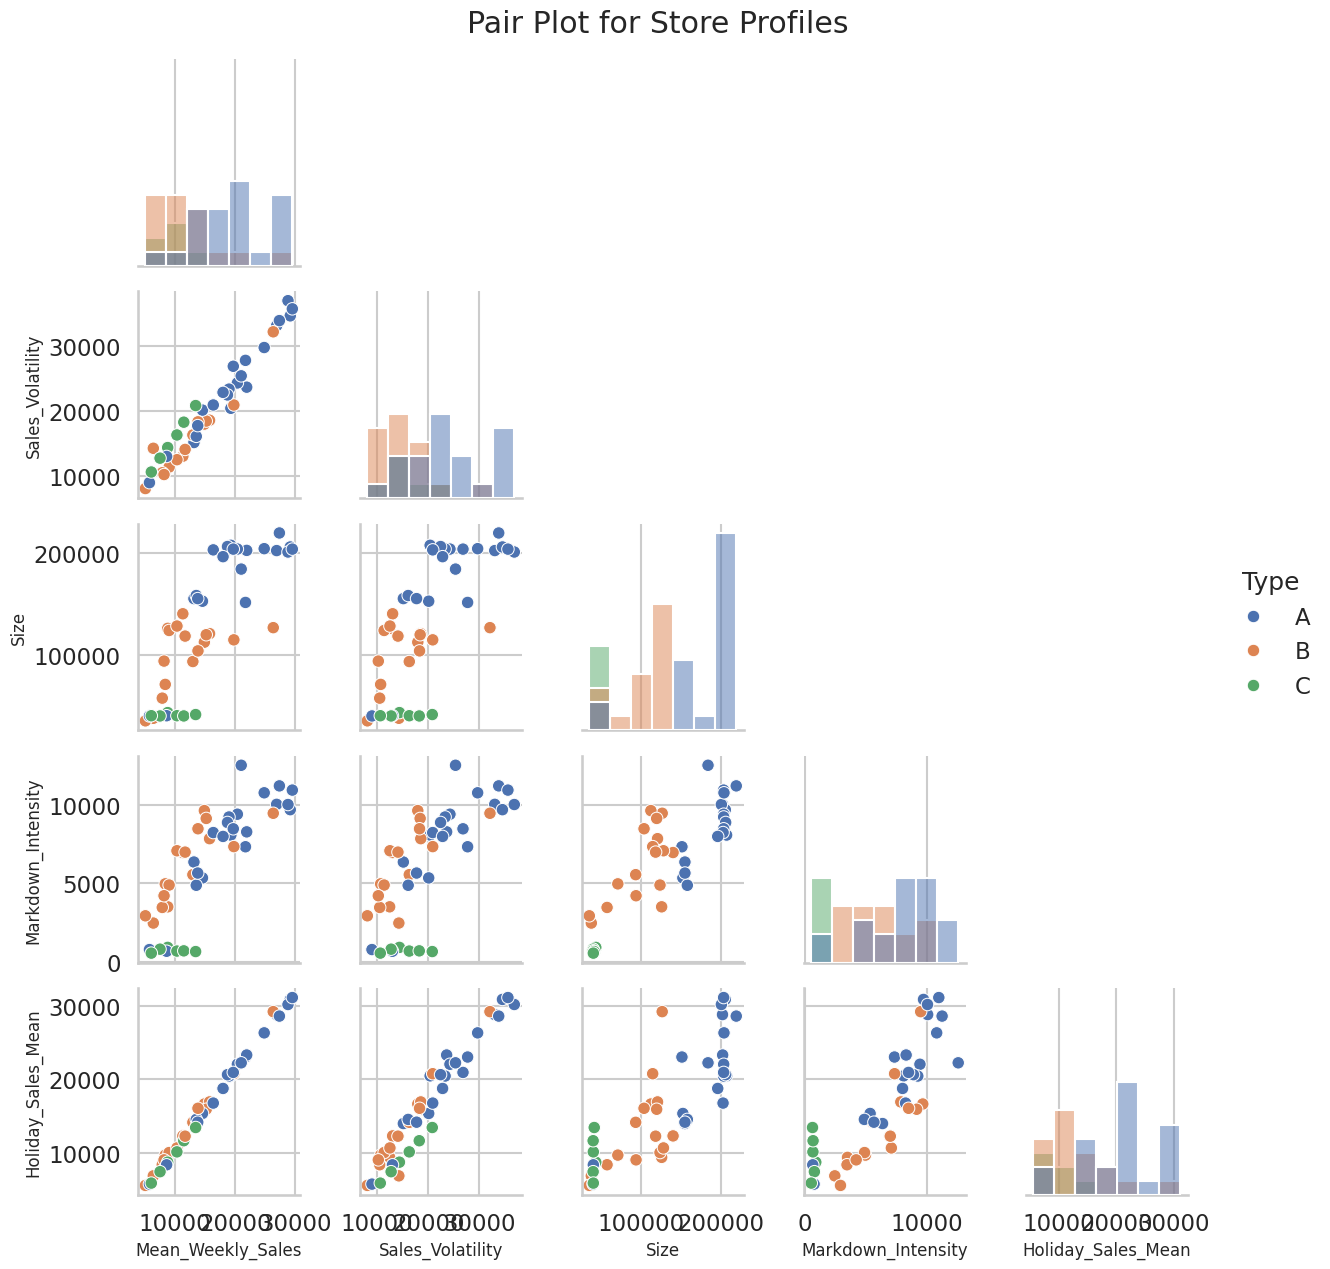

In [28]:
# Code Cell 27: Plot a pair plot for the store profile variables.

# A compact set of store-level variables is selected so the pair plot stays interpretable.
pairplot_columns = ["Mean_Weekly_Sales", "Sales_Volatility", "Size", "Markdown_Intensity", "Holiday_Sales_Mean", "Type"]

# The selected store profile variables are copied into a plotting frame.
pairplot_df = store_profiles[pairplot_columns].copy()

# The pair plot shows how key store variables separate by store type.
pairplot_grid = sns.pairplot(pairplot_df, hue="Type", diag_kind="hist", corner=True)

# A figure title keeps the multi-panel view well labeled.
pairplot_grid.fig.suptitle("Pair Plot for Store Profiles", y=1.02)
pairplot_grid.savefig(FIGURE_DIR / "store_profile_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


##### 1. Why did you pick the specific chart?
A pair plot was selected because the store profile table is compact enough to support multi-variable comparison without overwhelming the notebook.


🧩 A pair plot is used because it checks several store-profile relationships before clustering.


🔎 **Insight from the chart**

The store profiles do not all overlap randomly. Store size, mean sales, volatility, and markdown intensity show visible structure by store type. This supports the idea that stores can be grouped into meaningful operating segments.


💼 **Business use:** Store segmentation is justified because the stores show different profiles, not just different store IDs.


## ⚖️ ***5. Hypothesis Testing***


### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.


🧪 **Hypothesis testing plan**

The visual analysis suggested three business questions: holiday weeks may behave differently, store types may have different sales levels, and markdown intensity may have a relationship with sales. These tests check whether those observed patterns are statistically supported.


### Hypothetical Statement - 1


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


**Null hypothesis (H0):** The distribution of weekly sales during holiday weeks is the same as the distribution during non-holiday weeks.  
**Alternate hypothesis (H1):** The distribution of weekly sales during holiday weeks is different from the distribution during non-holiday weeks.


#### 2. Perform an appropriate statistical test.


In [29]:
# Code Cell 28: Perform a Mann-Whitney U test for holiday and non-holiday weekly sales.

# Split sales into holiday and non-holiday groups.
holiday_group = merged_df.loc[merged_df["Holiday_Week"] == 1, "Weekly_Sales_Clean"]
non_holiday_group = merged_df.loc[merged_df["Holiday_Week"] == 0, "Weekly_Sales_Clean"]

# Run the non-parametric test because retail sales are usually skewed.
holiday_test_statistic, holiday_p_value = mannwhitneyu(
    holiday_group,
    non_holiday_group,
    alternative="two-sided",
)

# Store the result in a readable table.
holiday_hypothesis_result_df = pd.DataFrame(
    {
        "Statistic": [holiday_test_statistic],
        "P_Value": [holiday_p_value],
        "Decision_at_5pct": [
            "Reject Null" if holiday_p_value < 0.05 else "Fail to Reject Null"
        ],
    }
)

# Display the test result.
display(holiday_hypothesis_result_df)


,Statistic,P_Value,Decision_at_5pct
0,"5,885,982,140.00",0.00,Reject Null


##### Which statistical test have you done to obtain P-Value?


The Mann-Whitney U test was used to obtain the p-value.


##### Why did you choose the specific statistical test?


The Mann-Whitney U test is suitable because it compares two independent groups: holiday weeks and non-holiday weeks. The output shows a **p-value of 0.00**, so the null hypothesis is rejected at the 5% level. This supports the chart finding that holiday and non-holiday sales distributions are not the same.


### Hypothetical Statement - 2


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


**Null hypothesis (H0):** Mean weekly sales are equal across store types A, B, and C.  
**Alternate hypothesis (H1):** At least one store type has a different mean weekly sales level.


#### 2. Perform an appropriate statistical test.


In [30]:
# Code Cell 29: Perform a one-way ANOVA test for average sales across store types.

# Create one sales group for each store type.
store_type_groups = [
    group["Weekly_Sales_Clean"].values
    for _, group in merged_df.groupby("Type")
]

# Run ANOVA to compare average sales across store types.
anova_statistic, anova_p_value = f_oneway(*store_type_groups)

# Store the result in a readable table.
store_type_hypothesis_result_df = pd.DataFrame(
    {
        "Statistic": [anova_statistic],
        "P_Value": [anova_p_value],
        "Decision_at_5pct": [
            "Reject Null" if anova_p_value < 0.05 else "Fail to Reject Null"
        ],
    }
)

# Display the test result.
display(store_type_hypothesis_result_df)


,Statistic,P_Value,Decision_at_5pct
0,"7,764.52",0.00,Reject Null


##### Which statistical test have you done to obtain P-Value?


A one-way ANOVA test was used to obtain the p-value.


##### Why did you choose the specific statistical test?


ANOVA is suitable because the comparison involves more than two groups: Store Types A, B, and C. The output shows a **p-value of 0.00**, so the null hypothesis is rejected. This means at least one store type has a meaningfully different average sales level.


### Hypothetical Statement - 3


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


**Null hypothesis (H0):** Markdown intensity has no monotonic relationship with weekly sales.  
**Alternate hypothesis (H1):** Markdown intensity has a monotonic relationship with weekly sales.


#### 2. Perform an appropriate statistical test.


In [31]:
# Code Cell 30: Perform a Spearman correlation test for markdown intensity and weekly sales.

# Keep only the two fields required for the correlation test.
markdown_correlation_df = merged_df[["Total_MarkDown", "Weekly_Sales_Clean"]].dropna()

# Spearman correlation checks whether markdown intensity moves with sales rank.
spearman_statistic, spearman_p_value = spearmanr(
    markdown_correlation_df["Total_MarkDown"],
    markdown_correlation_df["Weekly_Sales_Clean"],
)

# Store the result in a readable table.
markdown_hypothesis_result_df = pd.DataFrame(
    {
        "Statistic": [spearman_statistic],
        "P_Value": [spearman_p_value],
        "Decision_at_5pct": [
            "Reject Null" if spearman_p_value < 0.05 else "Fail to Reject Null"
        ],
    }
)

# Display the test result.
display(markdown_hypothesis_result_df)


,Statistic,P_Value,Decision_at_5pct
0,0.03,0.00,Reject Null


##### Which statistical test have you done to obtain P-Value?


Spearman rank correlation was used to obtain the p-value.


##### Why did you choose the specific statistical test?


Spearman correlation is suitable because markdown values are skewed and the relationship with sales may not be perfectly linear. The output shows a small positive statistic of about **0.03** with a **p-value of 0.00**. This means markdowns have a statistically detectable relationship with sales, but the strength is weak.
